In [16]:
from src.qsp_builder import build_qsp_unitary
from src.recover import build_corrected_qsp_phase_list

import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

In [ ]:
from src.qsp_builder import build_qsp_unitary
from src.recover import build_corrected_qsp_phase_list

phases = [np.pi / 3] * 4   # degree 3 QSP = 4 phases
theta = 0.4
epsilon = 1e-3

final_phases = build_corrected_qsp_phase_list(phases)
final_unitary = build_qsp_unitary(final_phases, theta, epsilon)

print(final_unitary)


[[-3.90931765e-01-0.91852318j  2.26305265e-05-0.05905525j]
 [-2.26305265e-05-0.05905525j -3.90931765e-01+0.91852318j]]


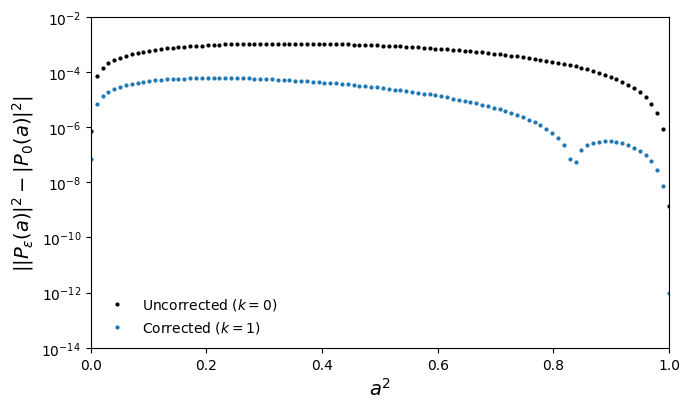

In [23]:
base_phases = [np.pi / 3] * 4   # degree 3 => 4 phases
epsilon = 1e-3

final_phases = build_corrected_qsp_phase_list(base_phases)

a2_grid = np.linspace(1e-4, 1 - 1e-4, 100)
uncorrected_error = np.zeros_like(a2_grid)
corrected_k1_error = np.zeros_like(a2_grid)

for i, a2 in enumerate(a2_grid):
    theta = np.arccos(np.sqrt(a2))

    ideal_unitary = build_qsp_unitary(base_phases, theta, 0.0)
    noisy_unitary = build_qsp_unitary(base_phases, theta, epsilon)
    final_unitary = build_qsp_unitary(final_phases, theta, epsilon)

    p0 = abs(ideal_unitary[0, 0]) ** 2
    p_uncorrected = abs(noisy_unitary[0, 0]) ** 2
    p_corrected_k1 = abs(final_unitary[0, 0]) ** 2

    uncorrected_error[i] = abs(p_uncorrected - p0)
    corrected_k1_error[i] = abs(p_corrected_k1 - p0)

plt.figure(figsize=(7, 4.2))
plt.semilogy(a2_grid, uncorrected_error, 'k.', ms=4, label='Uncorrected ($k=0$)')
plt.semilogy(a2_grid, corrected_k1_error, '.', color='tab:blue', ms=4, label='Corrected ($k=1$)')

plt.xlabel(r'$a^2$', fontsize=14)
plt.ylabel(r'$||P_\epsilon(a)|^2 - |P_0(a)|^2|$', fontsize=14)
plt.xlim(0, 1)
plt.ylim(1e-14, 1e-2)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [38]:
from qiskit import QuantumCircuit

def qsp_circuit_from_phases(phases, theta):
    qc = QuantumCircuit(1)
    qc.rz(-2 * phases[0], 0)

    for phi in phases[1:]:
        qc.rx(-2 * theta, 0)
        qc.rz(-2 * phi, 0)

    return qc
base_qc = qsp_circuit_from_phases(base_phases, theta)
corr_qc = qsp_circuit_from_phases(final_phases, theta)


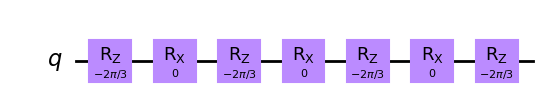

In [39]:
base_qc.draw(output='mpl')


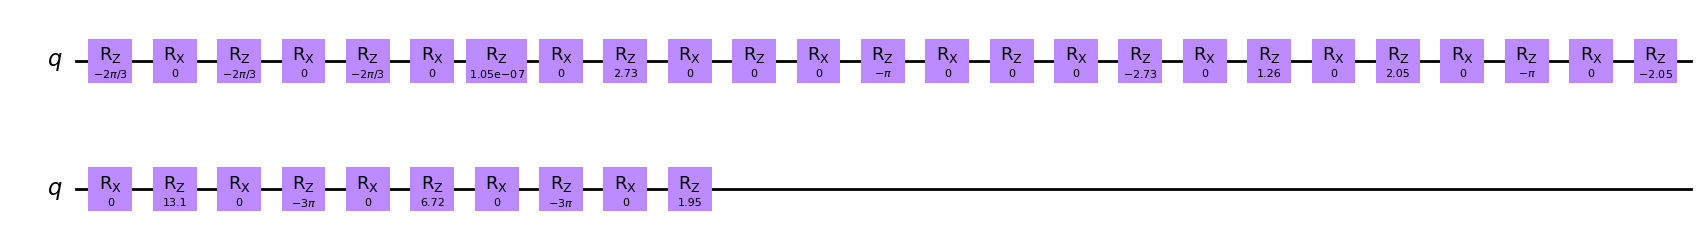

In [40]:
corr_qc.draw(output='mpl')